### Import Libraries

In [2]:
import torch
from torch import nn, optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
import pandas as pd
from sklearn import preprocessing as prep
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

### Load and Inspect the Dataset

In [4]:
df= pd.read_csv('IMDB-Dataset.csv')
lb= LabelEncoder()
df['sentiment']= lb.fit_transform(df['sentiment'])
df.head()
#print(len(df))

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


### BOW Using CountVectorizer

In [6]:
comments= df["review"].astype(str).tolist()
vocab_size= 5000
vectorize= CountVectorizer(max_features=vocab_size)
# TF-IDF Feature Extraction
vectorize= TfidfVectorizer(max_features=vocab_size)
x= vectorize.fit_transform(comments).toarray()
y= df["sentiment"].values

### devide data to train and test sets

In [8]:
X_train, X_test, Y_train, Y_test= train_test_split(x, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)


(40000, 5000) (10000, 5000) (40000,) (10000,)


### convert to PyTorch tensors

In [10]:
X_train_Tensor= torch.tensor(X_train, dtype= torch.float32)
X_test_Tensor= torch.tensor(X_test, dtype= torch.float32)
Y_train_Tensor = torch.tensor(Y_train, dtype=torch.long)
Y_test_Tensor = torch.tensor(Y_test, dtype=torch.long)


### create DataLoader for batching

In [12]:
train_dataset= TensorDataset(X_train_Tensor, Y_train_Tensor)
train_loader= DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataset= TensorDataset(X_test_Tensor, Y_test_Tensor)

### create MLP model

In [14]:
#create MLP model
class MLP(torch.nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(MLP, self).__init__()
        self.fc1 = torch.nn.Linear(input_size, hidden_size)
        self.relu = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(hidden_size, num_classes)
        self.dropout = torch.nn.Dropout(p=0.5)
        # self.bn1 = torch.nn.BatchNorm1d(hidden_size)
    
    def forward(self, x):
        out = self.fc1(x)
        # out = self.bn1(out)
        out = self.relu(out)
        # out = self.dropout(out)
        out = self.fc2(out)
        return out


In [15]:
model = MLP(input_size=vocab_size,
            hidden_size=64,
            num_classes=2)
# optimizer and loss function
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [16]:
num_epochs = 10
train_losses = []   
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_X.size(0)
    epoch_loss /= len(train_loader.dataset)
    train_losses.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

Epoch [1/10], Loss: 0.3156
Epoch [2/10], Loss: 0.2256
Epoch [3/10], Loss: 0.2088
Epoch [4/10], Loss: 0.1925
Epoch [5/10], Loss: 0.1710
Epoch [6/10], Loss: 0.1434
Epoch [7/10], Loss: 0.1110
Epoch [8/10], Loss: 0.0790
Epoch [9/10], Loss: 0.0515
Epoch [10/10], Loss: 0.0303


In [17]:
# model evaluation
model.eval()
y_pred=[]
y_true=[]
with torch.no_grad():
    for i in range(len(test_dataset)):
        inputs, label = test_dataset[i]
        inputs = inputs.unsqueeze(0)  # add batch dimension
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        y_pred.append(predicted.item())
        y_true.append(label.item())

Accuracy: 87.7
Precision: 88.7172
Recall: 86.6045
F1-score: 87.6481


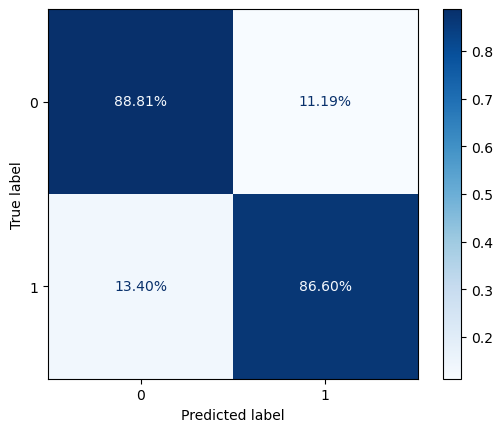

In [58]:
# evaluation metrics
accuracy = metrics.accuracy_score(y_true, y_pred)
precision = metrics.precision_score(y_true, y_pred)
recall = metrics.recall_score(y_true, y_pred)
f1 = metrics.f1_score(y_true, y_pred)
print(f"Accuracy: {accuracy * 100}\nPrecision: {precision* 100:.4f}\nRecall: {recall * 100:.4f}\nF1-score: {f1 * 100:.4f}")
cm = metrics.confusion_matrix(y_true, y_pred, normalize='true')
# display normalized confusion matrix with %
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
# disp.plot(cmap=plt.cm.Blues)
# plt.show()

# normalized confusion matrix
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues, values_format='.2%')
plt.show()